Saved rebuilt summary CSV with 144 models: test_eval_outputs/model_test_summary.csv
                                       name     model_type train_dataset_mode  \
12          fixed_splitnet_attn_darcy_0p001  splitnet_attn              fixed   
7            border_splitnet_attn_darcy_0p1  splitnet_attn             border   
5      border_pressure_attn_unet_darcy_0p01      attn_unet    border_pressure   
6   border_pressure_splitnet_attn_darcy_0p1  splitnet_attn    border_pressure   
13               fixed_splitnet_darcy_0p001       splitnet              fixed   
4                border_attn_unet_darcy_0p1      attn_unet             border   
14                 fixed_splitnet_darcy_1p0       splitnet              fixed   
10                fixed_attn_unet_darcy_0p1      attn_unet              fixed   
9                 fixed_attn_unet_darcy_0p0      attn_unet              fixed   

      training_mode  darcy_weight eval_dataset_mode  mean_mse_total  \
12  physics_limited         0.001 

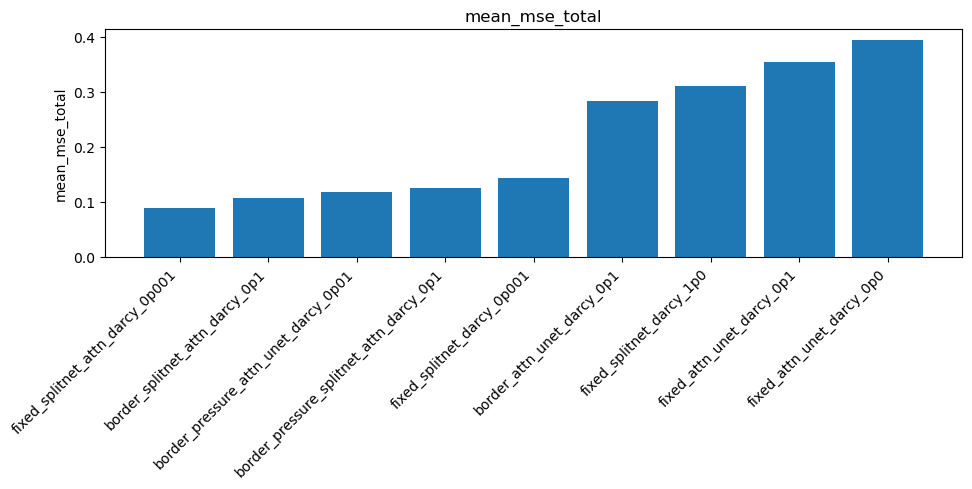

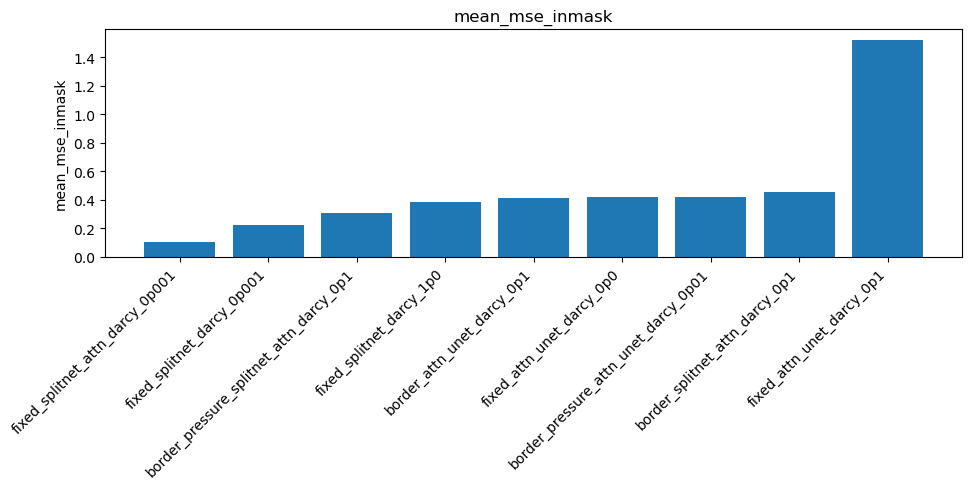

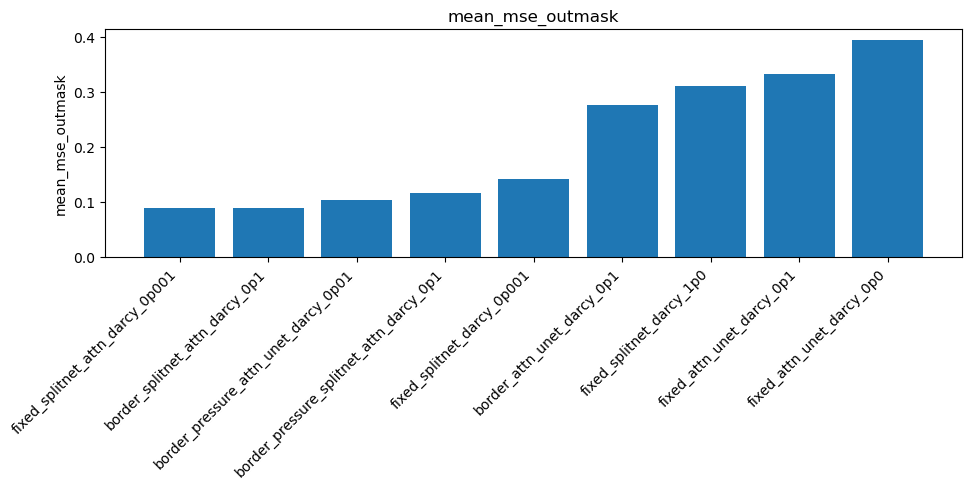

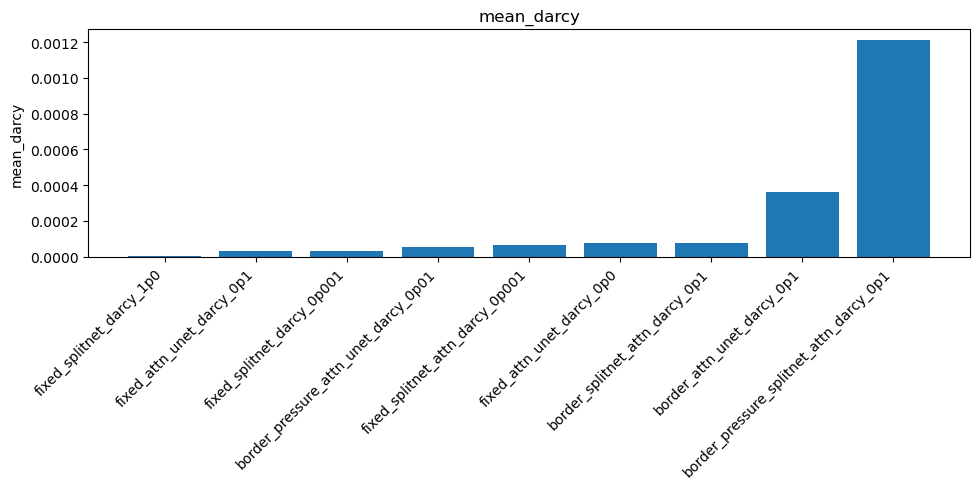

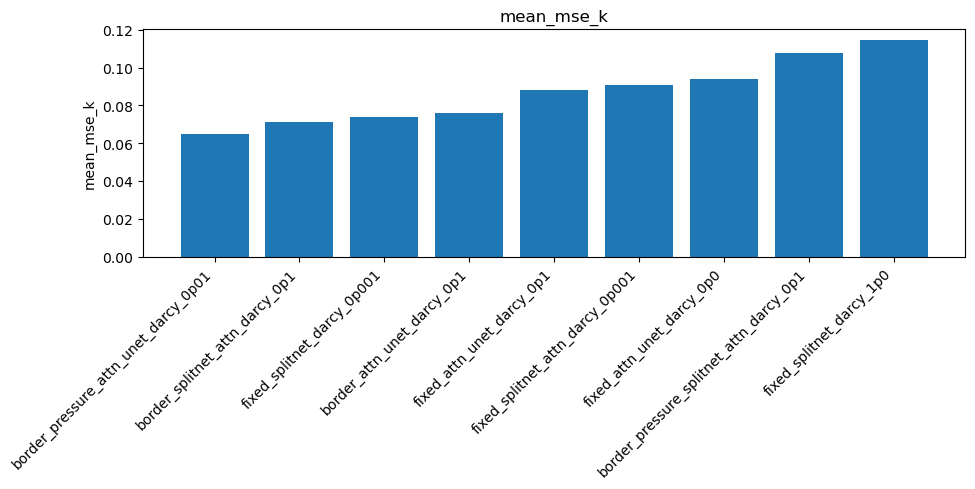

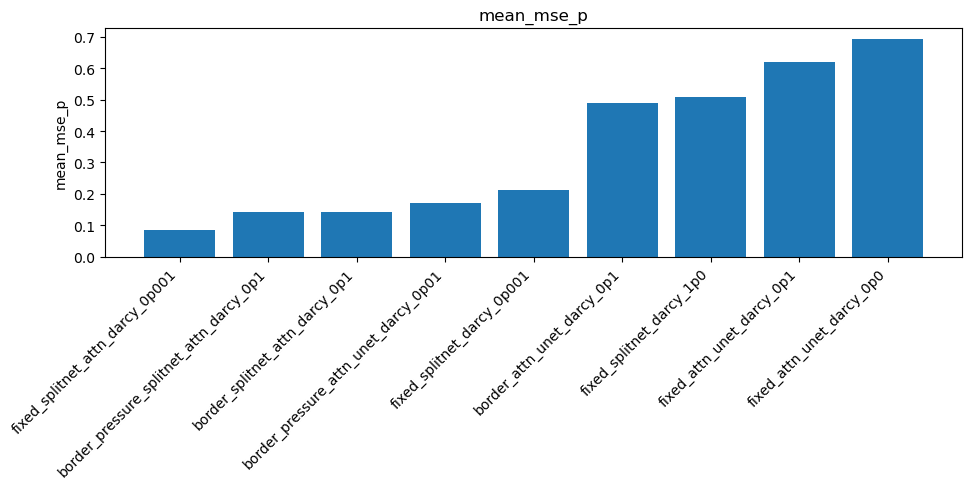

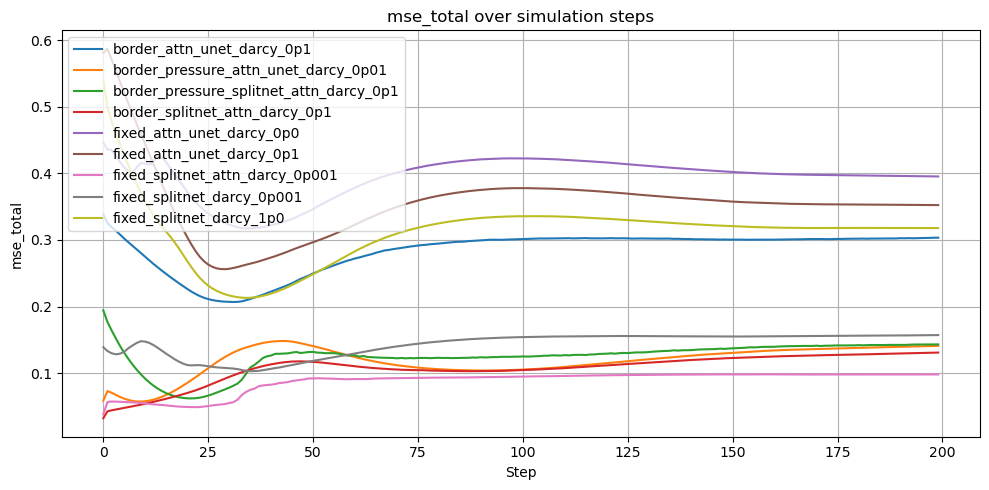

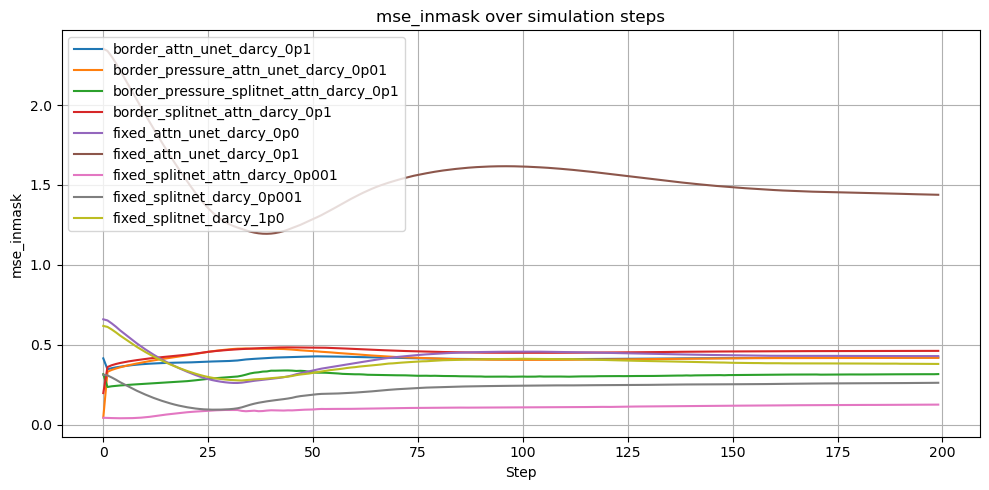

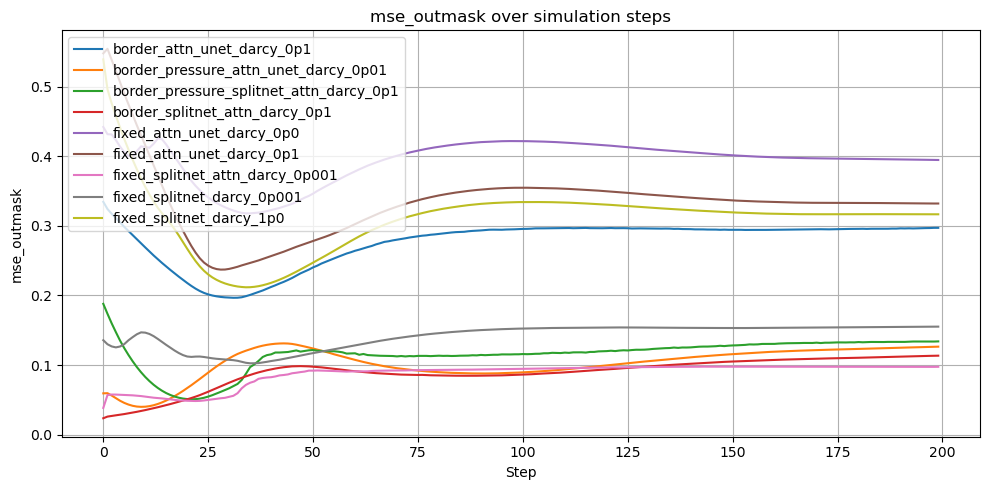

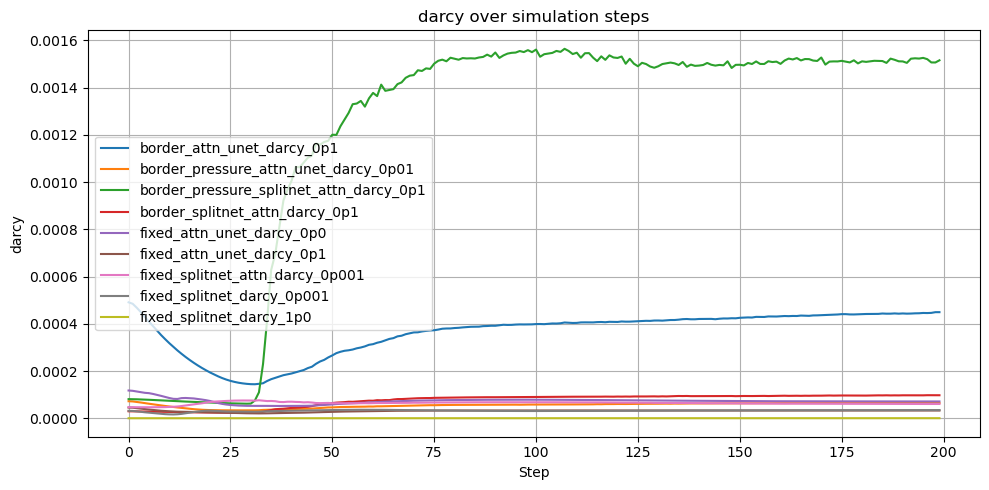

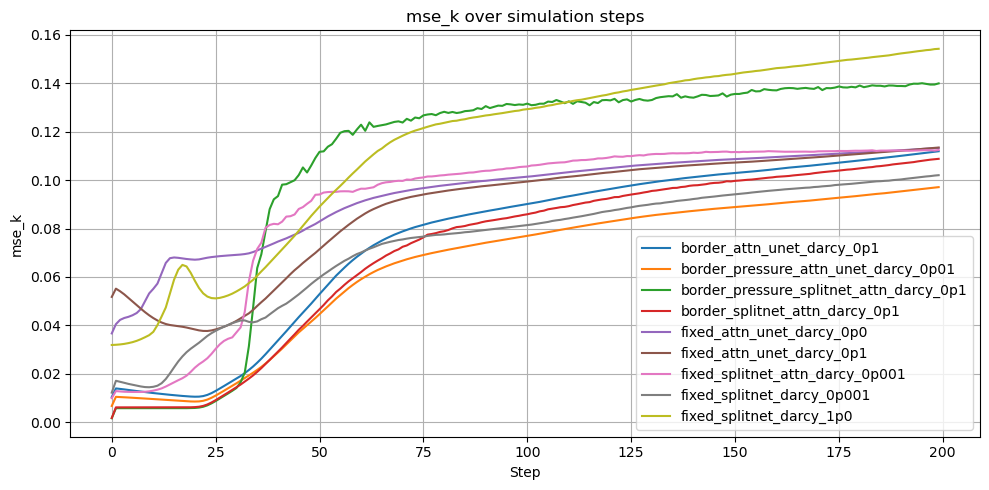

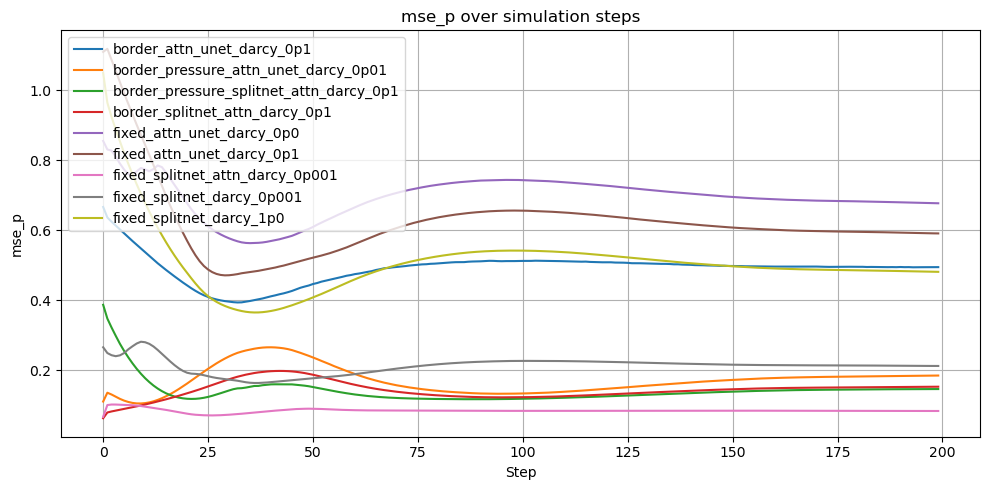

                                       name     model_type train_dataset_mode  \
12          fixed_splitnet_attn_darcy_0p001  splitnet_attn              fixed   
7            border_splitnet_attn_darcy_0p1  splitnet_attn             border   
5      border_pressure_attn_unet_darcy_0p01      attn_unet    border_pressure   
6   border_pressure_splitnet_attn_darcy_0p1  splitnet_attn    border_pressure   
13               fixed_splitnet_darcy_0p001       splitnet              fixed   
4                border_attn_unet_darcy_0p1      attn_unet             border   
14                 fixed_splitnet_darcy_1p0       splitnet              fixed   
10                fixed_attn_unet_darcy_0p1      attn_unet              fixed   
9                 fixed_attn_unet_darcy_0p0      attn_unet              fixed   

      training_mode  darcy_weight  mean_mse_total  mean_mse_inmask  \
12  physics_limited         0.001        0.087678         0.103033   
7   physics_limited         0.100        0.107216

In [12]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json


# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------

def load_summary(summary_csv="test_eval_outputs/model_test_summary.csv"):
    return pd.read_csv(summary_csv)


def load_npz(npz_path):
    path = Path(str(npz_path).replace("\\", "/"))

    if not path.exists():
        # fallback: search by filename anywhere under test_eval_outputs
        matches = list(Path("test_eval_outputs").rglob(path.name))
        if matches:
            path = matches[0]
        else:
            raise FileNotFoundError(f"Could not find NPZ: {npz_path}")

    data = np.load(path)
    return {k: data[k] for k in data.files}


def get_rows(summary_csv, model_names=None):
    df = load_summary(summary_csv)

    if model_names is None:
        return df

    if isinstance(model_names, str):
        model_names = [model_names]

    found = df[df["name"].isin(model_names)].copy()

    missing = sorted(set(model_names) - set(found["name"]))
    if missing:
        print("Missing models:")
        for m in missing:
            print("  -", m)

    return found


# -----------------------------------------------------------------------------
# Compact table comparison
# -----------------------------------------------------------------------------

def compare_table(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    sort_by="mean_mse_total",
):
    df = get_rows(summary_csv, model_names)

    cols = [
        "name",
        "model_type",
        "train_dataset_mode",
        "training_mode",
        "darcy_weight",
        "eval_dataset_mode",
        "mean_mse_total",
        "mean_nmse_total",
        "mean_darcy",
        "mean_mse_inmask",
        "mean_mse_outmask",
        "mean_mse_k",
        "mean_mse_p",
        "mean_mae_total",
        "mean_bias_total",
    ]

    cols = [c for c in cols if c in df.columns]
    out = df[cols].copy()

    if sort_by in out.columns:
        out = out.sort_values(sort_by)

    return out


# -----------------------------------------------------------------------------
# Bar plots from summary CSV
# -----------------------------------------------------------------------------

def plot_summary_metric(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    metric="mean_mse_total",
    sort=True,
):
    df = get_rows(summary_csv, model_names)

    if sort and metric in df.columns:
        df = df.sort_values(metric)

    plt.figure(figsize=(max(9, len(df) * 1.1), 5))
    plt.bar(df["name"], df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(metric)
    plt.tight_layout()
    plt.show()


def plot_core_summary(summary_csv="test_eval_outputs/model_test_summary.csv", model_names=None):
    metrics = [
        "mean_mse_total",
        "mean_mse_inmask",
        "mean_mse_outmask",
        "mean_darcy",
        "mean_mse_k",
        "mean_mse_p",
    ]

    for metric in metrics:
        plot_summary_metric(summary_csv, model_names, metric=metric)


# -----------------------------------------------------------------------------
# Step/time curve plots from NPZ
# -----------------------------------------------------------------------------

def mean_over_types_and_sims(arr):
    """
    Phase 1 arrays are shaped [types, sims, steps].
    This returns one curve over steps.
    """
    return np.nanmean(arr, axis=(0, 1))


def plot_metric_over_steps(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    metric="mse_total",
):
    df = get_rows(summary_csv, model_names)

    plt.figure(figsize=(10, 5))

    for _, row in df.iterrows():
        data = load_npz(row["npz_path"])

        if metric not in data:
            print(f"Skipping {row['name']}: no metric {metric}")
            continue

        curve = mean_over_types_and_sims(data[metric])
        steps = np.arange(len(curve))

        plt.plot(steps, curve, label=row["name"])

    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(f"{metric} over simulation steps")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_core_step_curves(summary_csv="test_eval_outputs/model_test_summary.csv", model_names=None):
    metrics = [
        "mse_total",
        "mse_inmask",
        "mse_outmask",
        "darcy",
        "mse_k",
        "mse_p",
    ]

    for metric in metrics:
        plot_metric_over_steps(summary_csv, model_names, metric=metric)


# -----------------------------------------------------------------------------
# Compare one metric split by model groups
# -----------------------------------------------------------------------------

def plot_grouped_by_darcy(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_type=None,
    train_dataset_mode=None,
    metric="mean_mse_total",
):
    df = load_summary(summary_csv)

    if model_type is not None:
        df = df[df["model_type"] == model_type]

    if train_dataset_mode is not None:
        df = df[df["train_dataset_mode"] == train_dataset_mode]

    df = df.sort_values("darcy_weight")

    plt.figure(figsize=(8, 5))
    plt.plot(df["darcy_weight"], df[metric], marker="o")
    plt.xscale("symlog", linthresh=0.001)
    plt.xlabel("Darcy weight")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Darcy weight")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return df[["name", "model_type", "train_dataset_mode", "darcy_weight", metric]]



def rebuild_summary_csv_from_jsons(
    results_dir="test_eval_outputs",
    out_csv="test_eval_outputs/model_test_summary.csv",
):
    rows = []

    for path in Path(results_dir).rglob("eval_*_summary.json"):
        with open(path, "r") as f:
            summary = json.load(f)

        config = summary.get("config", {})

        row = {
            "name": config.get("name", path.stem.replace("eval_", "").replace("_summary", "")),
            "model_type": config.get("model_type"),
            "train_dataset_mode": config.get("train_dataset_mode"),
            "training_mode": config.get("training_mode"),
            "darcy_weight": config.get("darcy_weight"),
            "eval_dataset_mode": config.get("eval_dataset_mode"),
            "model_path": config.get("model_path"),
            "npz_path": summary.get("npz_path"),
            "mean_mse_total": summary.get("mean_mse_total"),
            "mean_nmse_total": summary.get("mean_nmse_total"),
            "mean_darcy": summary.get("mean_darcy"),
            "mean_mse_inmask": summary.get("mean_mse_inmask"),
            "mean_mse_outmask": summary.get("mean_mse_outmask"),
            "mean_mse_k": summary.get("mean_mse_k"),
            "mean_mse_p": summary.get("mean_mse_p"),
            "mean_mae_total": summary.get("mean_mae_total"),
            "mean_bias_total": summary.get("mean_bias_total"),
        }

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("name")
    df.to_csv(out_csv, index=False)
    print(f"Saved rebuilt summary CSV with {len(df)} models: {out_csv}")
    return df


# -----------------------------------------------------------------------------
# Best model finder
# -----------------------------------------------------------------------------

def rank_models(
    summary_csv="test_eval_outputs/model_test_summary.csv",
    model_names=None,
    metric="mean_mse_total",
    ascending=True,
    top_n=10,
):
    df = get_rows(summary_csv, model_names)

    cols = [
        "name",
        "model_type",
        "train_dataset_mode",
        "training_mode",
        "darcy_weight",
        metric,
        "mean_mse_inmask",
        "mean_mse_outmask",
        "mean_darcy",
    ]

    cols = [c for c in cols if c in df.columns]

    return df[cols].sort_values(metric, ascending=ascending).head(top_n)


# -----------------------------------------------------------------------------
# Example usage
# -----------------------------------------------------------------------------

if __name__ == "__main__":
    summary_csv = "test_eval_outputs/model_test_summary.csv"

    rebuild_summary_csv_from_jsons(
        results_dir="test_eval_outputs",
        out_csv=summary_csv,
    )

    models_to_compare = [
        "border_attn_unet_darcy_0p1",
        "border_pressure_attn_unet_darcy_0p01",
        "border_pressure_splitnet_attn_darcy_0p1",
        "border_splitnet_attn_darcy_0p1",
        "fixed_attn_unet_darcy_0p0",
        "fixed_attn_unet_darcy_0p1",
        "fixed_splitnet_attn_darcy_0p001",
        "fixed_splitnet_darcy_0p001",
        "fixed_splitnet_darcy_1p0",
    ]

    print(compare_table(summary_csv, models_to_compare))
    plot_core_summary(summary_csv, models_to_compare)
    plot_core_step_curves(summary_csv, models_to_compare)
    print(rank_models(summary_csv, models_to_compare, metric="mean_mse_total"))


================ Official broad comparison ================
                                                 name     model_type  \
16  baseline_fixed_splitnet_attn_baseline_full_nod...  splitnet_attn   
18     baseline_fixed_attn_unet_baseline_full_nodarcy      attn_unet   
9       official_fixed_physics_limited_unet_darcy_0p1           unet   
15    official_border_physics_limited_unet_darcy_10p0           unet   
8       official_fixed_physics_limited_unet_darcy_5p0           unet   
11     official_fixed_physics_limited_unet_darcy_10p0           unet   
10      official_fixed_physics_limited_unet_darcy_1p0           unet   
7   official_border_physics_limited_splitnet_darcy...       splitnet   
13     official_border_physics_limited_unet_darcy_0p1           unet   
3   official_fixed_physics_limited_splitnet_darcy_...       splitnet   
0   official_fixed_physics_limited_splitnet_darcy_5p0       splitnet   
1   official_fixed_physics_limited_splitnet_darcy_0p1       splitnet   
17 

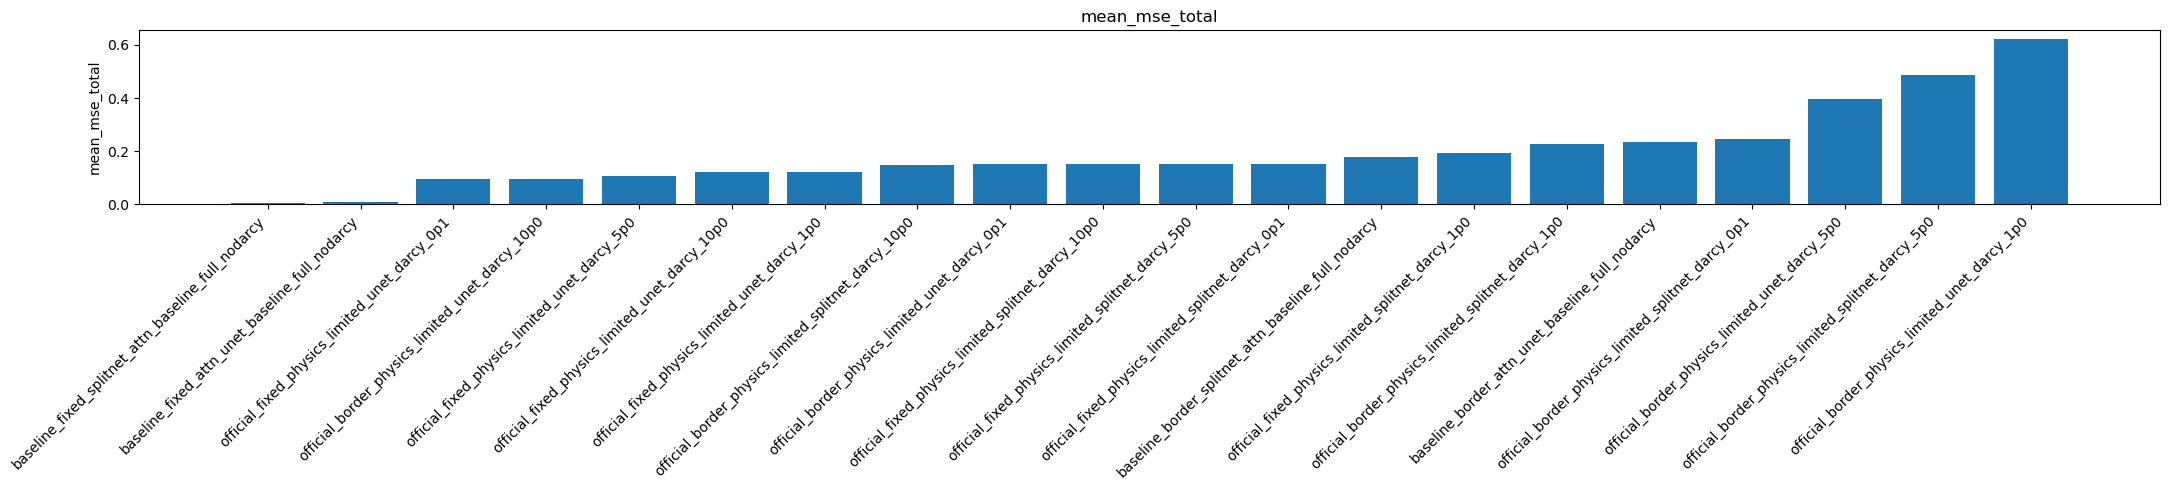

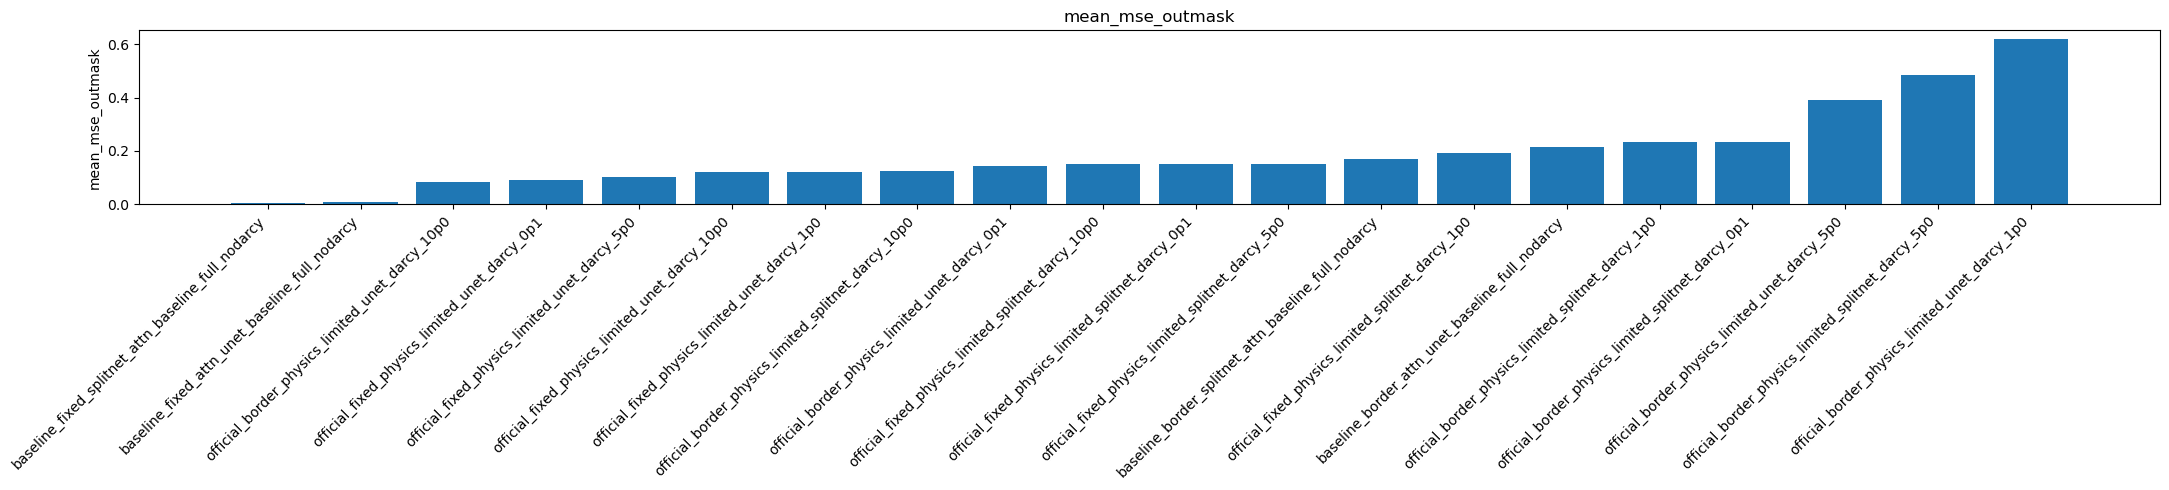

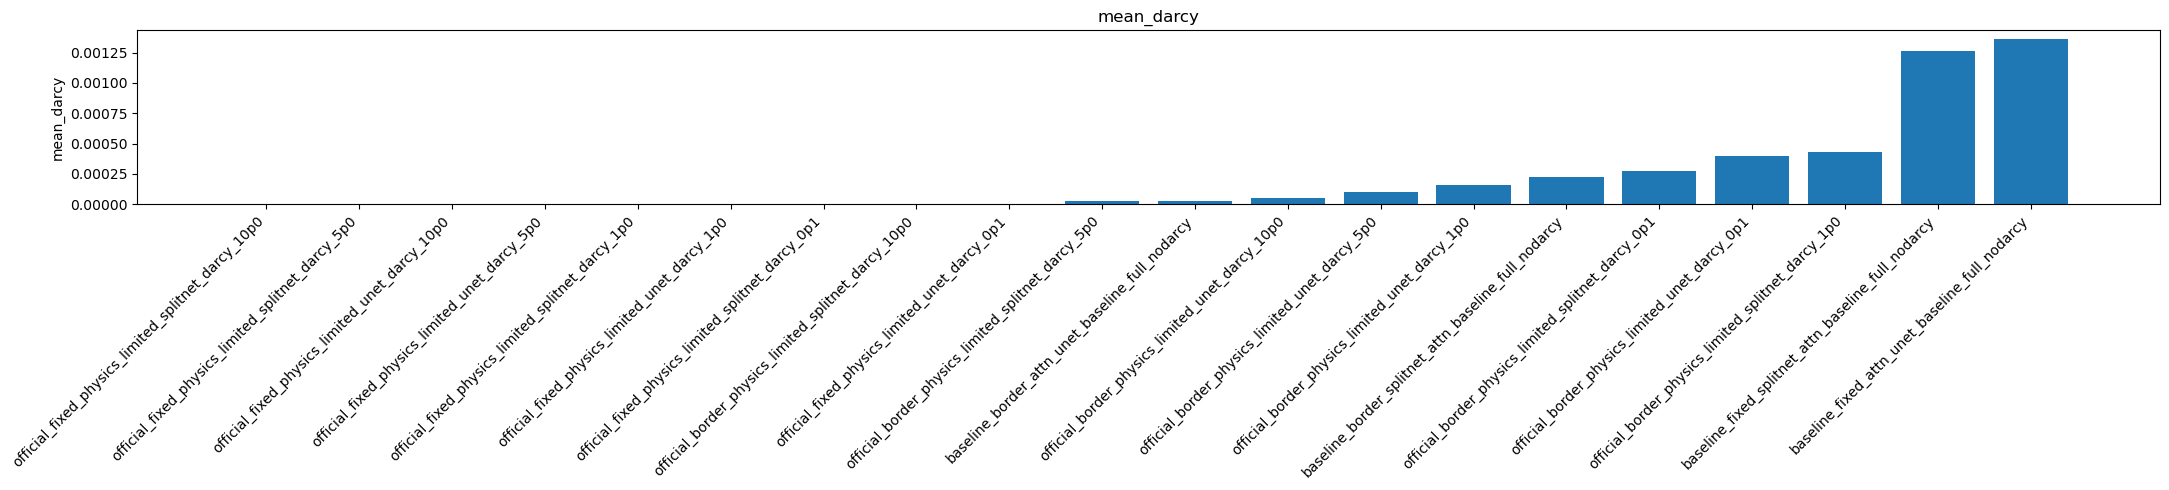

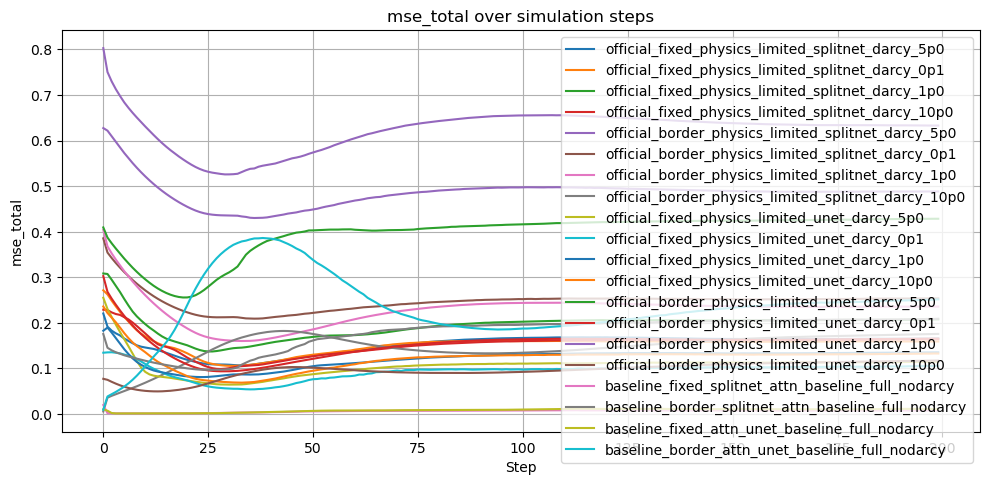

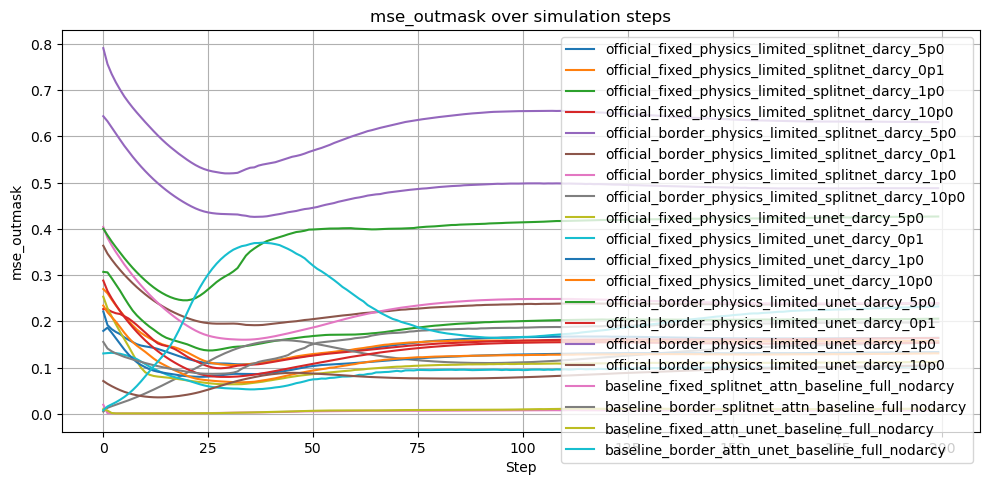

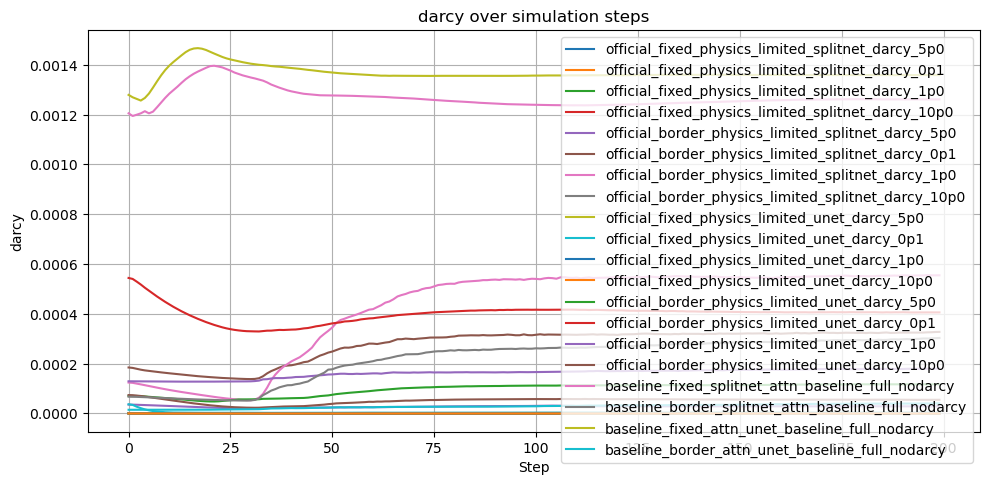


================ Official prof_unet fixed Darcy weights ================
Empty DataFrame
Columns: [name, model_type, train_dataset_mode, training_mode, darcy_weight, eval_dataset_mode, mean_mse_total, mean_nmse_total, mean_darcy, mean_mse_inmask, mean_mse_outmask, mean_mse_k, mean_mse_p, mean_mae_total, mean_bias_total]
Index: []


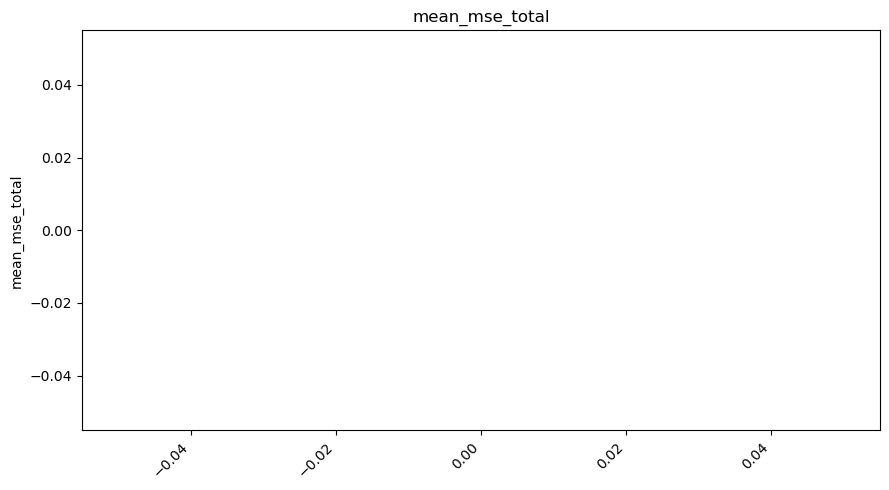

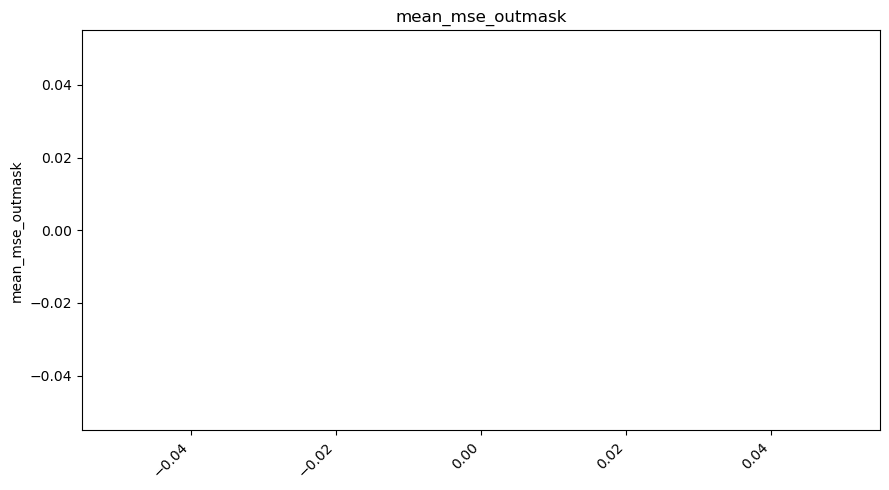

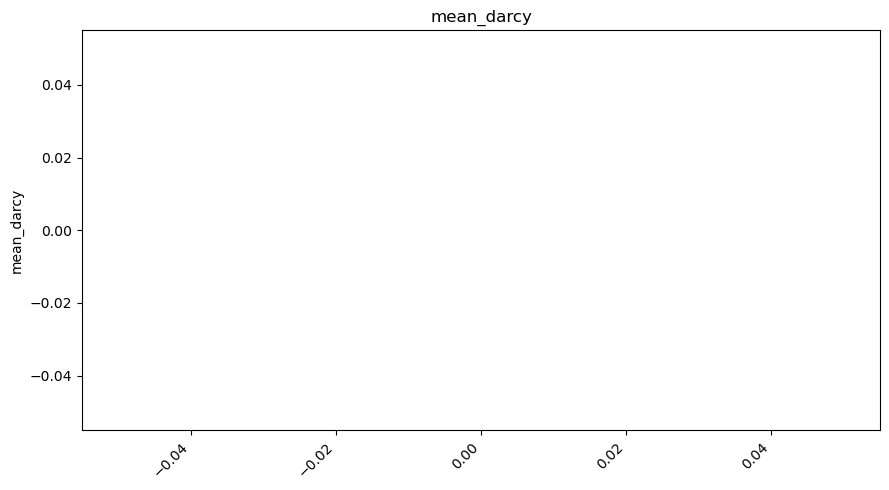

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


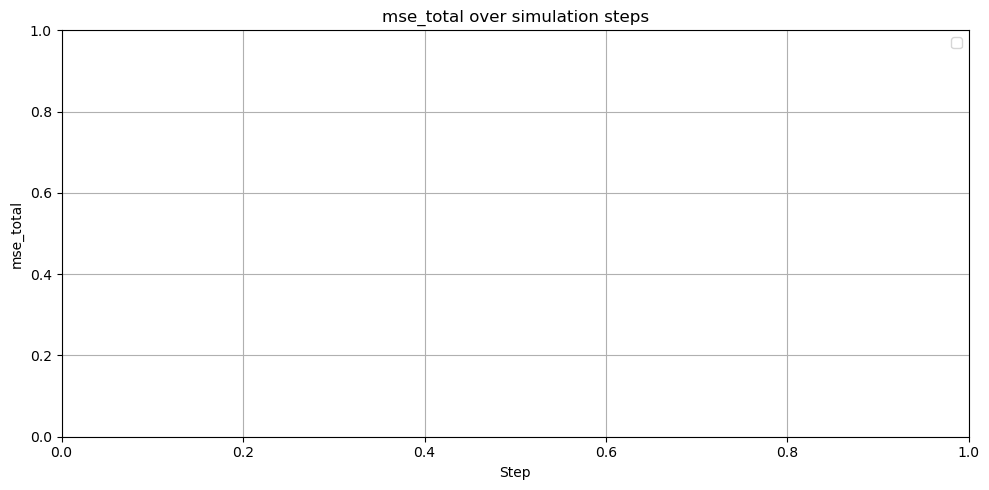

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


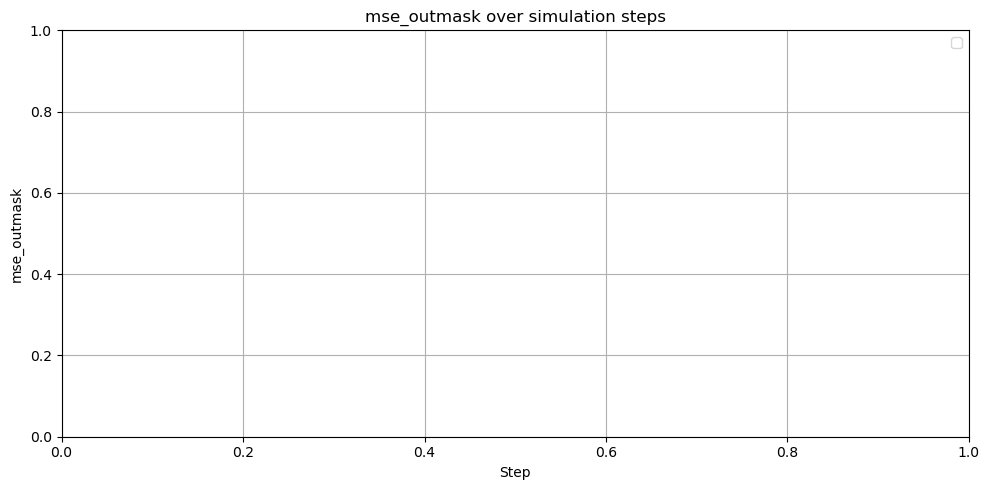

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


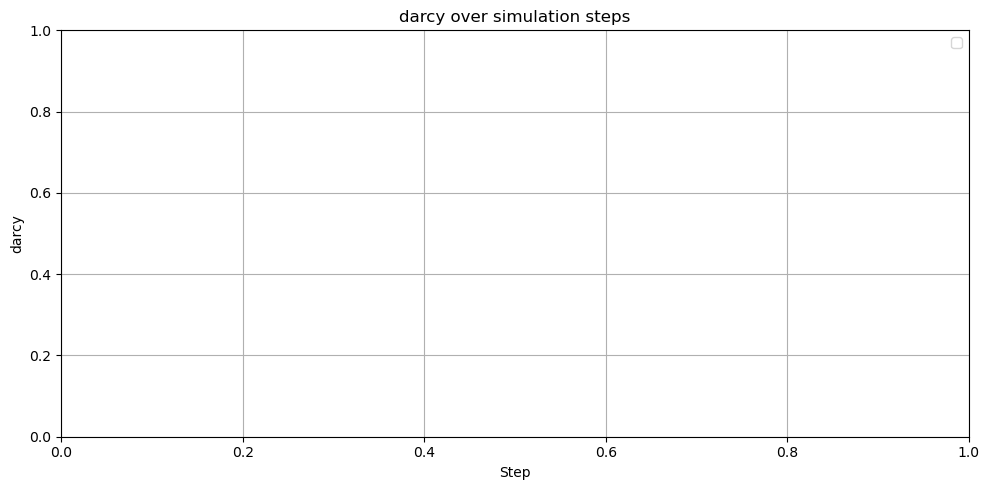


================ Official prof_unet border Darcy weights ================
Empty DataFrame
Columns: [name, model_type, train_dataset_mode, training_mode, darcy_weight, eval_dataset_mode, mean_mse_total, mean_nmse_total, mean_darcy, mean_mse_inmask, mean_mse_outmask, mean_mse_k, mean_mse_p, mean_mae_total, mean_bias_total]
Index: []


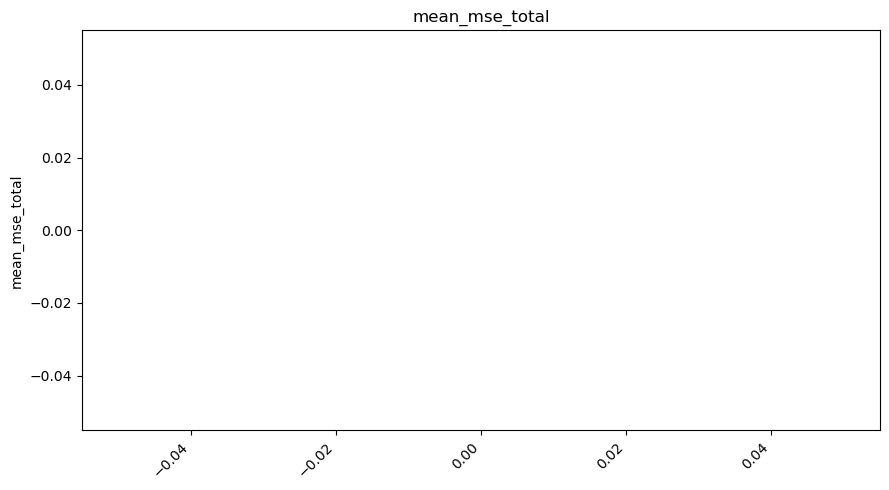

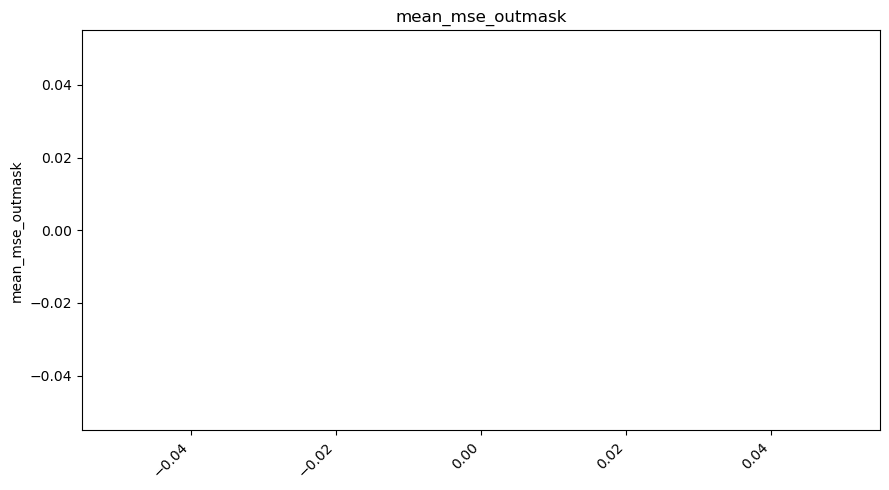

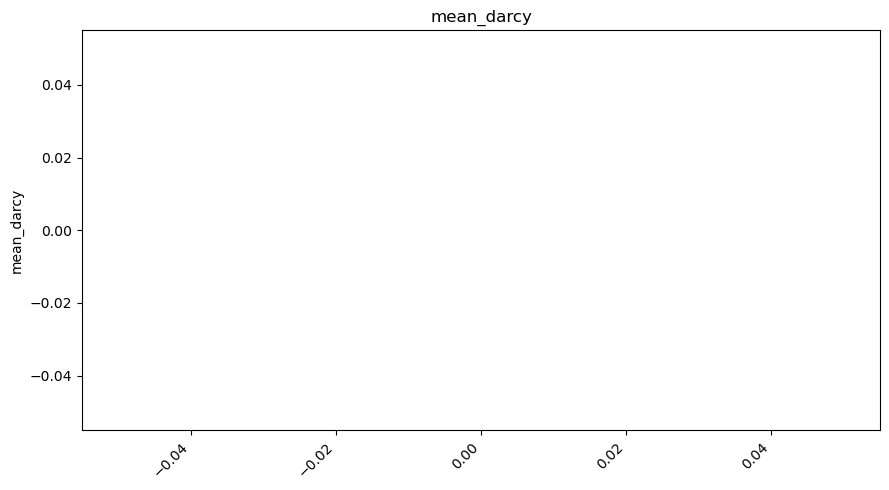

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


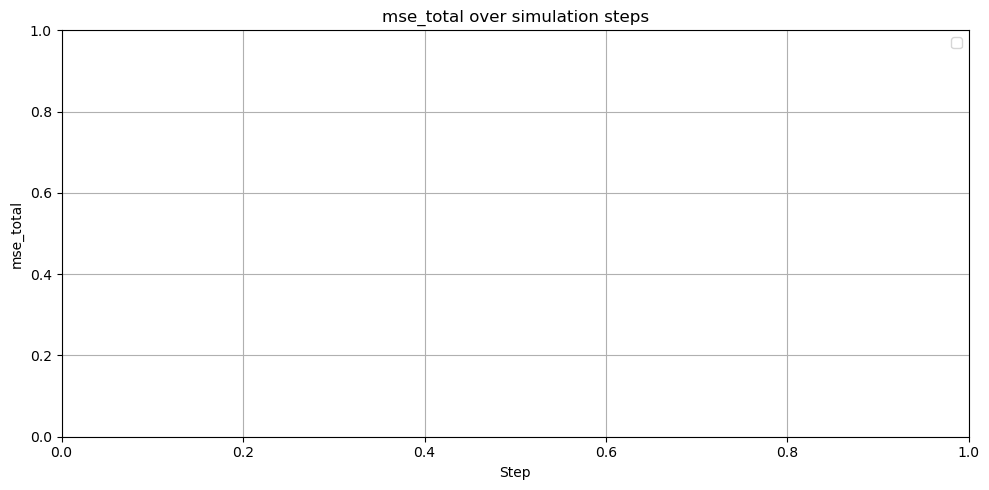

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


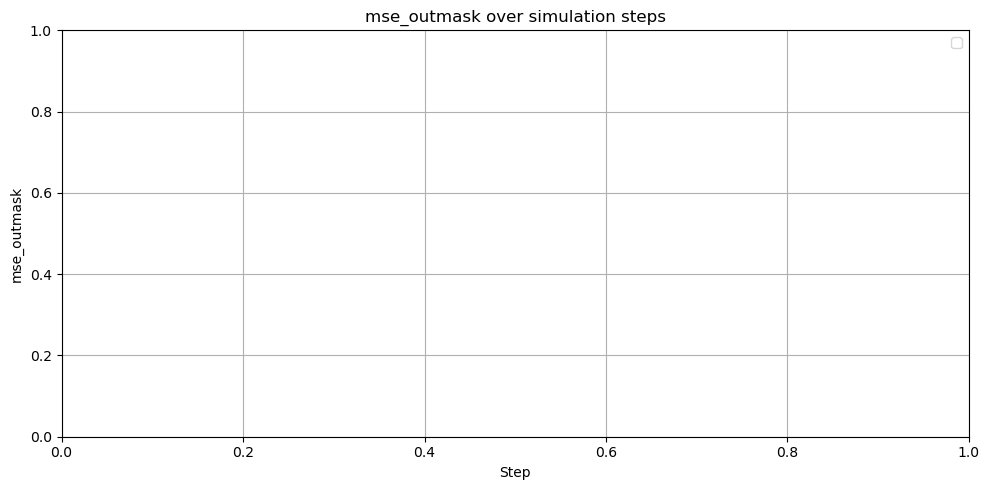

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


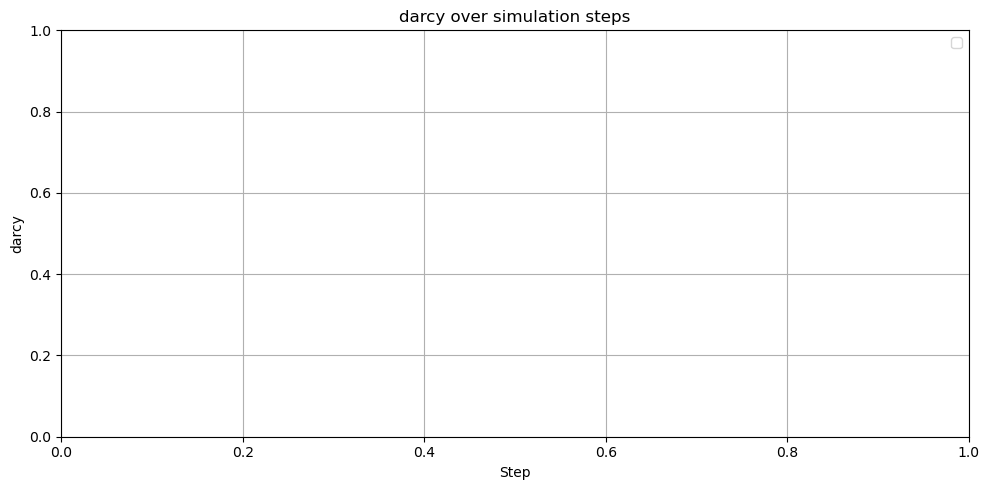


================ Official baseline_full no-Darcy comparison ================
                                                 name     model_type  \
16  baseline_fixed_splitnet_attn_baseline_full_nod...  splitnet_attn   
18     baseline_fixed_attn_unet_baseline_full_nodarcy      attn_unet   
17  baseline_border_splitnet_attn_baseline_full_no...  splitnet_attn   
19    baseline_border_attn_unet_baseline_full_nodarcy      attn_unet   

   train_dataset_mode  training_mode  darcy_weight eval_dataset_mode  \
16              fixed  baseline_full           0.0             fixed   
18              fixed  baseline_full           0.0             fixed   
17             border  baseline_full           0.0             fixed   
19             border  baseline_full           0.0             fixed   

    mean_mse_total  mean_nmse_total  mean_darcy  mean_mse_inmask  \
16        0.005909         0.020830    0.001268         0.001684   
18        0.007806         0.027422    0.001366         0.002016

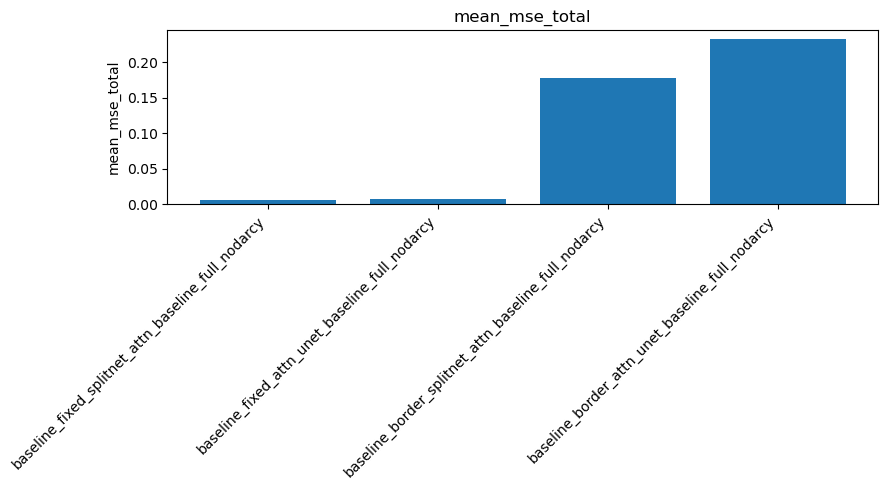

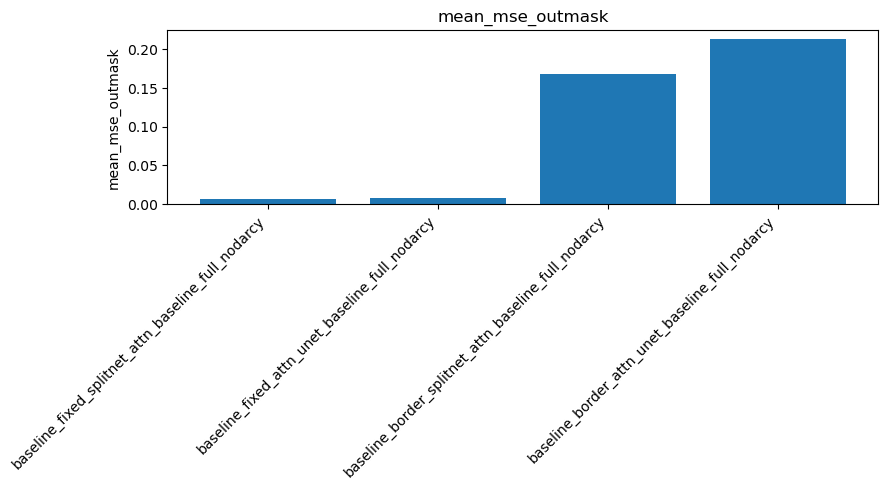

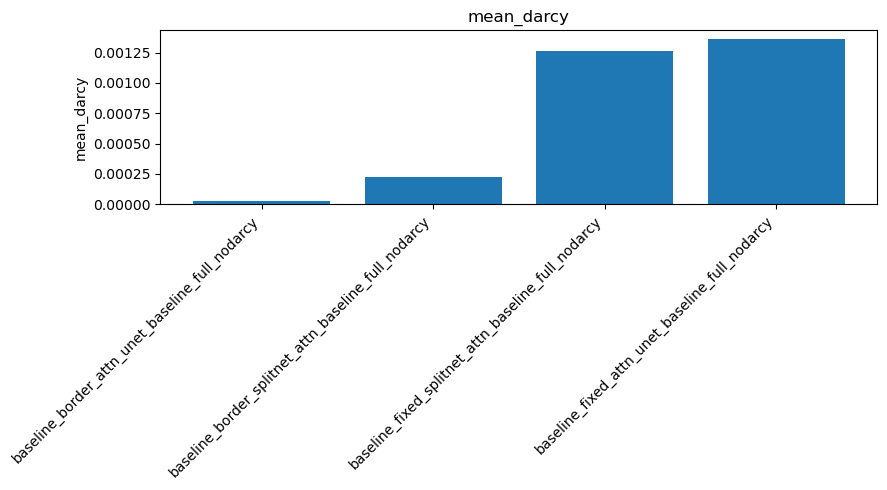

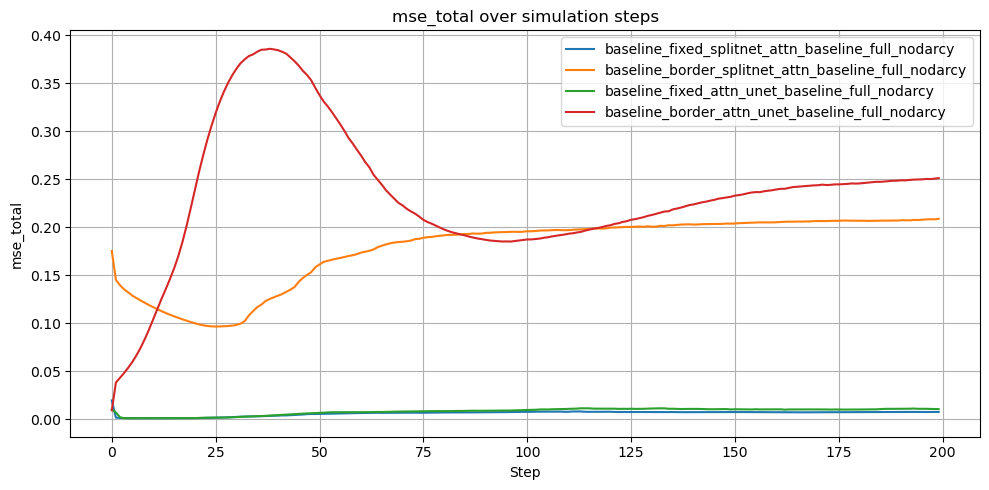

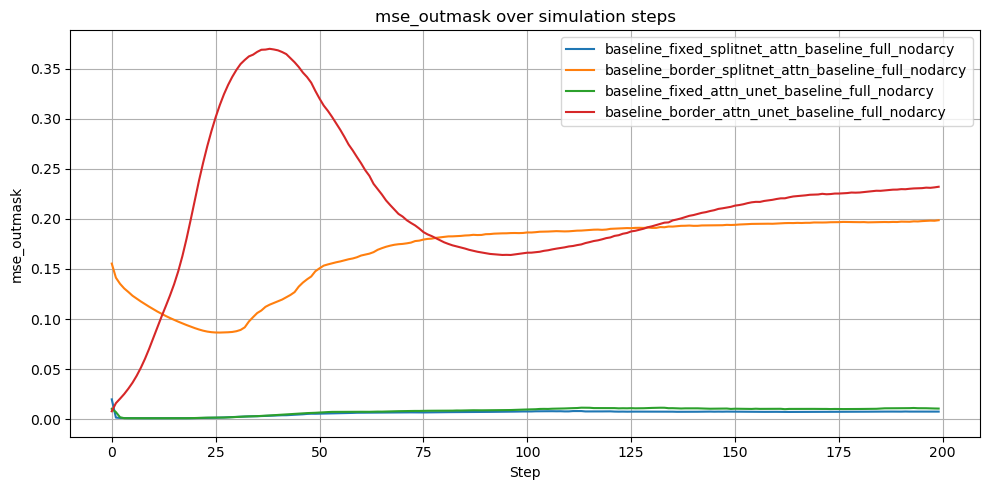

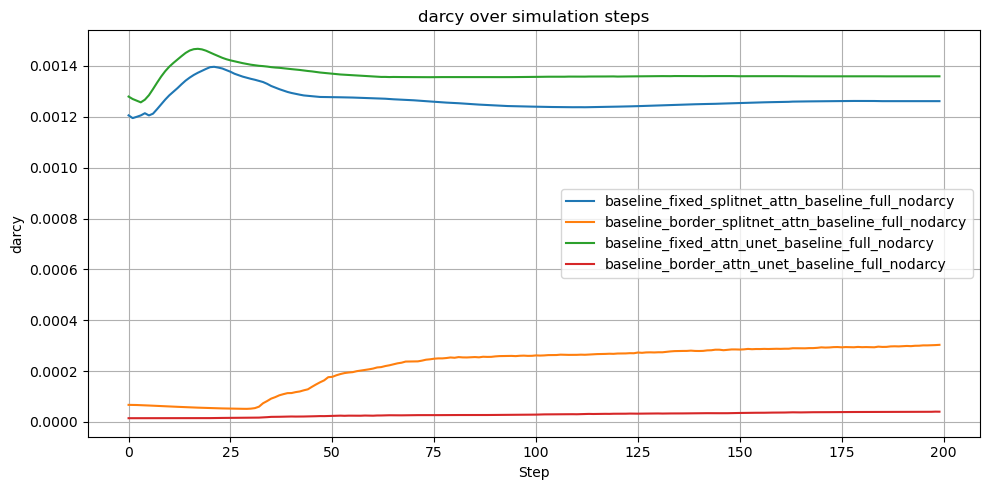


================ prof_unet fixed: Darcy vs baseline ================
Empty DataFrame
Columns: [name, model_type, train_dataset_mode, training_mode, darcy_weight, eval_dataset_mode, mean_mse_total, mean_nmse_total, mean_darcy, mean_mse_inmask, mean_mse_outmask, mean_mse_k, mean_mse_p, mean_mae_total, mean_bias_total]
Index: []


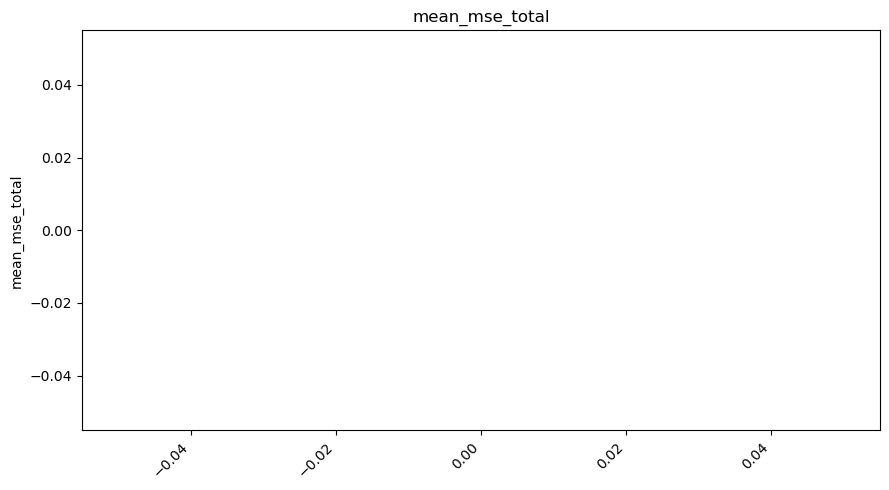

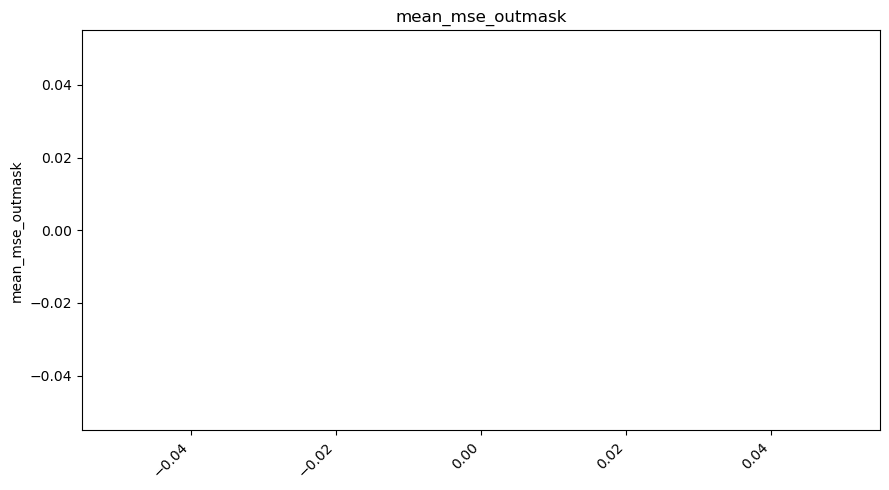

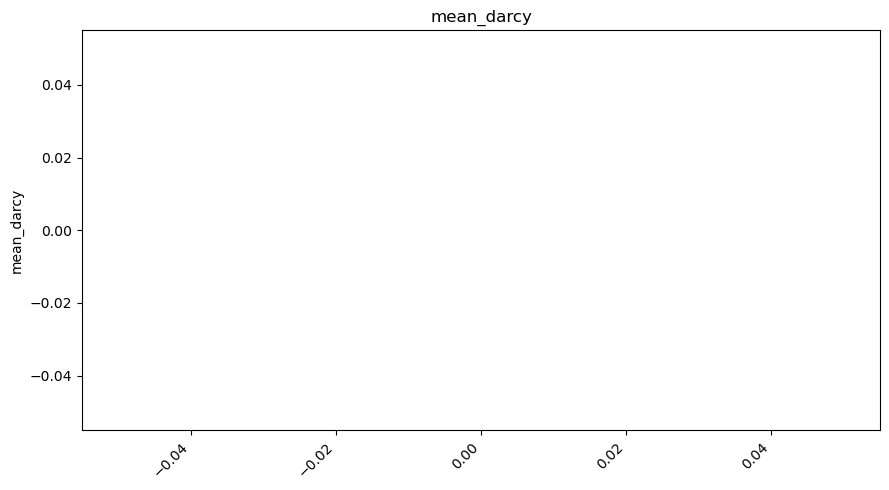

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


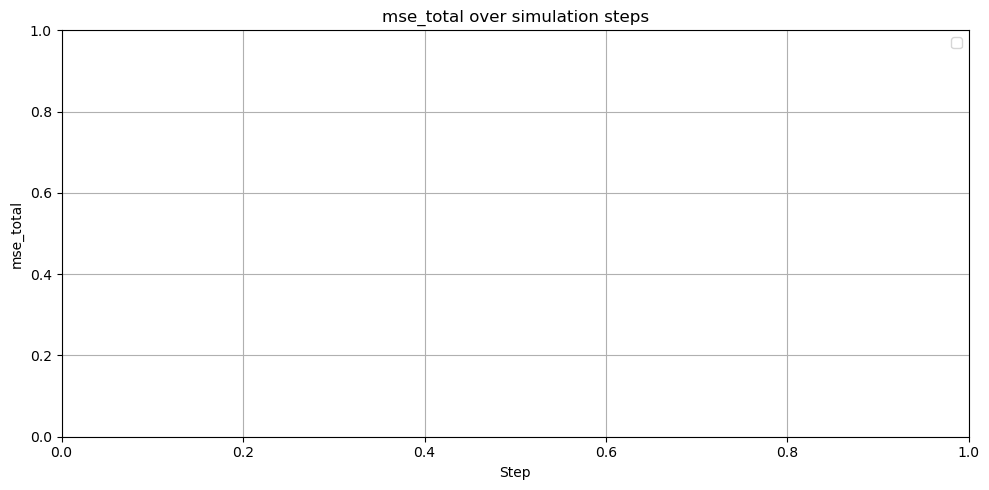

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


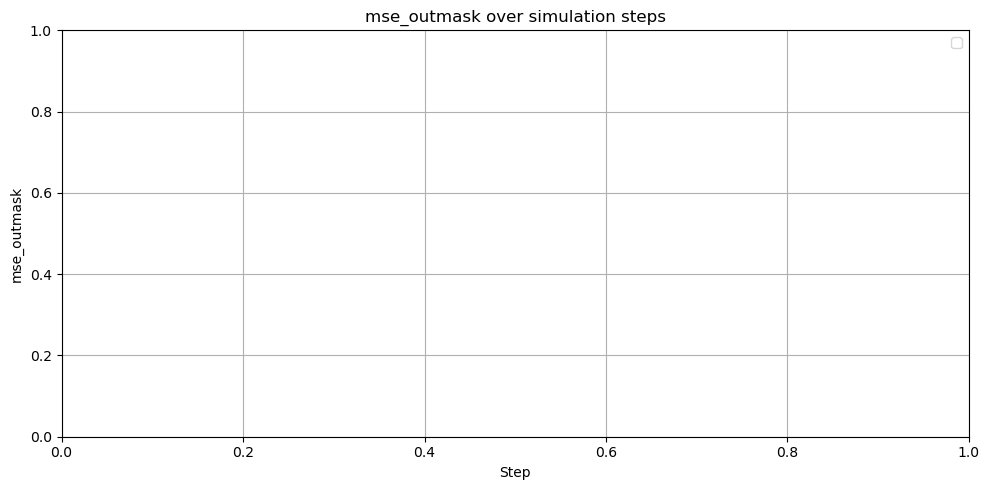

/var/folders/qm/z45q_dj168lbjph6mvbqnhg40000gn/T/ipykernel_17696/4185835850.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


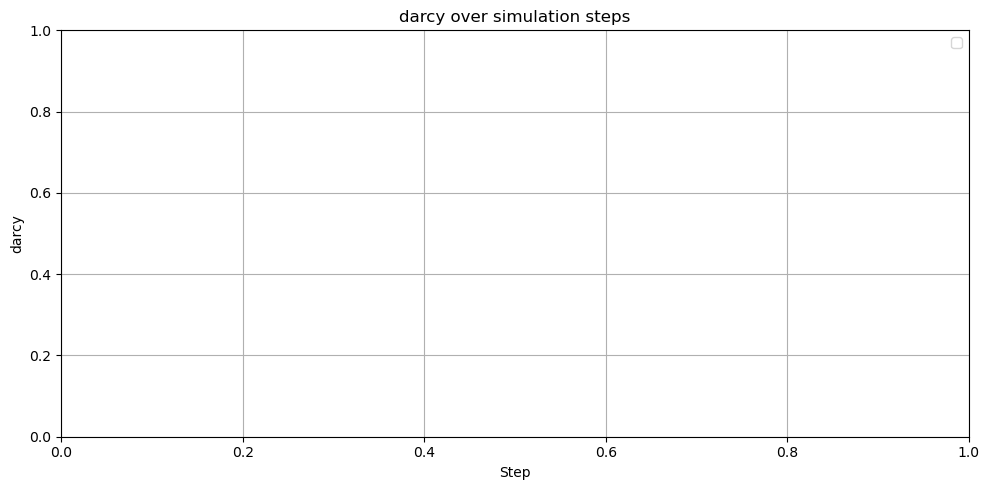

In [18]:
# -----------------------------------------------------------------------------
# Comparison group helpers
# -----------------------------------------------------------------------------

def names_matching(
    summary_csv,
    model_type=None,
    train_dataset_mode=None,
    training_mode=None,
    contains=None,
):
    df = load_summary(summary_csv)

    if model_type is not None:
        df = df[df["model_type"] == model_type]

    if train_dataset_mode is not None:
        df = df[df["train_dataset_mode"] == train_dataset_mode]

    if training_mode is not None:
        df = df[df["training_mode"] == training_mode]

    if contains is not None:
        for text in contains:
            df = df[df["name"].str.contains(text, na=False)]

    return df["name"].tolist()


def compare_group(summary_csv, group_name, model_names, sort_by="mean_mse_total"):
    print(f"\n================ {group_name} ================")
    print(compare_table(summary_csv, model_names, sort_by=sort_by))

    plot_summary_metric(summary_csv, model_names, metric="mean_mse_total")
    plot_summary_metric(summary_csv, model_names, metric="mean_mse_outmask")
    plot_summary_metric(summary_csv, model_names, metric="mean_darcy")

    plot_metric_over_steps(summary_csv, model_names, metric="mse_total")
    plot_metric_over_steps(summary_csv, model_names, metric="mse_outmask")
    plot_metric_over_steps(summary_csv, model_names, metric="darcy")


# -----------------------------------------------------------------------------
# Official model comparisons
# -----------------------------------------------------------------------------

official_csv = "test_eval_outputs/all_model_test_summary.csv"

# 1. Broad official comparison: all official/baseline models
official_all = names_matching(official_csv)

compare_group(
    official_csv,
    "Official broad comparison",
    official_all,
)


# 2. Official prof_unet Darcy sweep: fixed
official_prof_fixed = names_matching(
    official_csv,
    model_type="prof_unet",
    train_dataset_mode="fixed",
    training_mode="physics_limited",
)

compare_group(
    official_csv,
    "Official prof_unet fixed Darcy weights",
    official_prof_fixed,
)


# 3. Official prof_unet Darcy sweep: border
official_prof_border = names_matching(
    official_csv,
    model_type="prof_unet",
    train_dataset_mode="border",
    training_mode="physics_limited",
)

compare_group(
    official_csv,
    "Official prof_unet border Darcy weights",
    official_prof_border,
)


# 4. Baseline full comparison only
official_baselines = names_matching(
    official_csv,
    training_mode="baseline_full",
)

compare_group(
    official_csv,
    "Official baseline_full no-Darcy comparison",
    official_baselines,
)


# 5. Physics vs baseline for same model family
prof_unet_fixed_all = names_matching(
    official_csv,
    model_type="prof_unet",
    train_dataset_mode="fixed",
)

compare_group(
    official_csv,
    "prof_unet fixed: Darcy vs baseline",
    prof_unet_fixed_all,
)

In [14]:
# -----------------------------------------------------------------------------
# Data amount comparisons
# -----------------------------------------------------------------------------

data_csv = "test_eval_outputs/data_amount_test_summary.csv"

# 6. Broad data amount comparison
data_all = names_matching(data_csv)

compare_group(
    data_csv,
    "Data amount broad comparison",
    data_all,
)


# 7. SplitNet attention: does Darcy help as sim count changes?
splitnet_attn_data = names_matching(
    data_csv,
    model_type="splitnet_attn",
)

compare_group(
    data_csv,
    "Data amount: splitnet_attn all runs",
    splitnet_attn_data,
)


# 8. attn_unet: does Darcy help as sim count changes?
attn_unet_data = names_matching(
    data_csv,
    model_type="attn_unet",
)

compare_group(
    data_csv,
    "Data amount: attn_unet all runs",
    attn_unet_data,
)


# 9. prof_unet: does Darcy help as sim count changes?
prof_unet_data = names_matching(
    data_csv,
    model_type="prof_unet",
)

compare_group(
    data_csv,
    "Data amount: prof_unet all runs",
    prof_unet_data,
)

FileNotFoundError: [Errno 2] No such file or directory: 'test_eval_outputs/data_amount_test_summary.csv'

In [7]:
# -----------------------------------------------------------------------------
# Specific research-question comparisons
# -----------------------------------------------------------------------------

# 10. Only 25 sims: low-data comparison
low_data_25 = [
    name for name in names_matching(data_csv)
    if "_sims_25" in name
]

compare_group(
    data_csv,
    "Low data only: 25 sims",
    low_data_25,
)


# 11. Only 100 sims: higher-data comparison
data_100 = [
    name for name in names_matching(data_csv)
    if "_sims_100" in name
]

compare_group(
    data_csv,
    "Higher data only: 100 sims",
    data_100,
)


# 12. Darcy weight 1.0 only across architectures and sim counts
darcy_1_data = names_matching(
    data_csv,
    training_mode="physics_limited",
    darcy_weight=1.0,
)

compare_group(
    data_csv,
    "Data amount: Darcy weight 1.0 across models",
    darcy_1_data,
)


# 13. Darcy weight 10.0 only across architectures and sim counts
darcy_10_data = names_matching(
    data_csv,
    training_mode="physics_limited",
    darcy_weight=10.0,
)

compare_group(
    data_csv,
    "Data amount: Darcy weight 10.0 across models",
    darcy_10_data,
)


# 14. Baselines only across sim counts
baseline_data = names_matching(
    data_csv,
    training_mode="baseline_full",
)

compare_group(
    data_csv,
    "Data amount: baseline_full across sim counts",
    baseline_data,
)

NameError: name 'data_csv' is not defined

In [ ]:
compare_group(data_csv, "Low data only: 25 sims", low_data_25)
compare_group(data_csv, "Higher data only: 100 sims", data_100)
compare_group(data_csv, "Data amount: baseline_full across sim counts", baseline_data)
compare_group(data_csv, "Data amount: Darcy weight 1.0 across models", darcy_1_data)
compare_group(data_csv, "Data amount: Darcy weight 10.0 across models", darcy_10_data)

In [15]:
df = pd.read_csv("test_eval_outputs/model_test_summary.csv")

print(df[df["name"].str.contains("prof_unet", na=False)][
    ["name", "model_type", "train_dataset_mode", "training_mode", "darcy_weight"]
].to_string(index=False))

                                                       name model_type train_dataset_mode   training_mode  darcy_weight
        official_border_physics_limited_prof_unet_darcy_0p1  prof_unet             border physics_limited         0.100
        official_border_physics_limited_prof_unet_darcy_1p0  prof_unet             border physics_limited         1.000
        official_border_physics_limited_prof_unet_darcy_5p0  prof_unet             border physics_limited         5.000
         official_fixed_physics_limited_prof_unet_darcy_0p1  prof_unet              fixed physics_limited         0.100
        official_fixed_physics_limited_prof_unet_darcy_10p0  prof_unet              fixed physics_limited        10.000
         official_fixed_physics_limited_prof_unet_darcy_1p0  prof_unet              fixed physics_limited         1.000
         official_fixed_physics_limited_prof_unet_darcy_5p0  prof_unet              fixed physics_limited         5.000
           quick_border_physics_limited_

In [16]:
import json

path = "test_eval_outputs/official_darcy/eval_official_fixed_physics_limited_prof_unet_darcy_0p1_summary.json"

with open(path, "r") as f:
    s = json.load(f)

print(s["config"])

{'name': 'official_fixed_physics_limited_prof_unet_darcy_0p1', 'model_path': 'official_darcy\\final\\fixed_physics_limited_prof_unet_darcy_0p1_best_state.pt', 'model_type': 'prof_unet', 'train_dataset_mode': 'fixed', 'training_mode': 'physics_limited', 'darcy_weight': 0.1, 'eval_dataset_mode': 'fixed', 'channels': 'KP', 'test_sims_path': '../test_sims.npy', 'sim_max_exclusive': 250, 'steps': [0, 200], 'types': [0], 'points_per_side': 3, 'radius': 5, 'results_dir': 'test_eval_outputs/official_darcy', 'dataset_kwargs': None}


In [19]:
official_prof_fixed = names_matching(
    official_csv,
    contains=["official_fixed", "prof_unet", "physics_limited"],
)